In [1]:
!pip install pandas matplotlib seaborn lxml html5lib requests

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
url = "https://www.worldometers.info/population/countries-in-africa-by-population/"

data = pd.read_html(url)[0]

data.head()

HTTPError: HTTP Error 403: Forbidden

In [4]:
import pandas as pd
import requests

url = "https://www.worldometers.info/population/countries-in-africa-by-population/"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

data = pd.read_html(response.text)[0]

data.head()

/tmp/ipykernel_4696/1065376930.py:12: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  data = pd.read_html(response.text)[0]


,#,Country (or dependency),Population (2026),Yearly Change,Net Change,Density (P/KmÂ²),Land Area (KmÂ²),Migrants (net),Fert. Rate,Median Age,Urban Pop %,World Share
0,1,Nigeria,242431832,2.06%,4904050,266,910770,"â2,810",4.2,18,56%,2.92%
1,2,Ethiopia,138902185,2.53%,3430134,139,1000000,27298,3.7,19,23%,1.67%
2,3,Egypt,120101175,1.47%,1735180,121,995450,"â52,287",2.7,25,41%,1.45%
3,4,DR Congo,116452162,3.21%,3619689,51,2267050,"â28,843",5.8,16,45%,1.40%
4,5,Tanzania,72563780,2.86%,2017915,82,885800,"â25,275",4.4,18,41%,0.87%


In [5]:
data.columns = [
    "Rank", "Country", "Population",
    "Yearly_Change", "Net_Change",
    "Density", "Land_Area",
    "Migrants", "Fertility_Rate",
    "Median_Age", "Urban_Population",
    "World_Share"
]

In [6]:
data["Yearly_Change"] = data["Yearly_Change"].str.replace('%','')
data["Urban_Population"] = data["Urban_Population"].str.replace('%','')
data["World_Share"] = data["World_Share"].str.replace('%','')

In [7]:
numeric_columns = [
    "Population",
    "Yearly_Change",
    "Net_Change",
    "Density",
    "Land_Area",
    "Migrants",
    "Fertility_Rate",
    "Median_Age",
    "Urban_Population",
    "World_Share"
]

data[numeric_columns] = data[numeric_columns].apply(pd.to_numeric, errors='coerce')

In [8]:
data = data.dropna()

In [9]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 15 entries, 1 to 56
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Rank              15 non-null     int64  
 1   Country           15 non-null     object 
 2   Population        15 non-null     int64  
 3   Yearly_Change     15 non-null     float64
 4   Net_Change        15 non-null     float64
 5   Density           15 non-null     int64  
 6   Land_Area         15 non-null     int64  
 7   Migrants          15 non-null     float64
 8   Fertility_Rate    15 non-null     float64
 9   Median_Age        15 non-null     int64  
 10  Urban_Population  15 non-null     float64
 11  World_Share       15 non-null     float64
dtypes: float64(6), int64(5), object(1)
memory usage: 1.5+ KB


,Rank,Population,Yearly_Change,Net_Change,Density,Land_Area,Migrants,Fertility_Rate,Median_Age,Urban_Population,World_Share
count,15.000000,1.500000e+01,15.000000,1.500000e+01,15.000000,1.500000e+01,15.000000,15.000000,15.000000,15.000000,15.000000
mean,30.400000,2.576346e+07,2.127333,5.923098e+05,72.533333,6.353527e+05,30858.666667,3.353333,22.800000,53.933333,0.309200
std,17.891738,3.708626e+07,0.689653,9.037719e+05,88.585606,5.900126e+05,69571.151049,1.021810,5.894307,22.942371,0.446095
min,2.000000,1.349590e+05,1.090000,2.180000e+03,2.000000,4.600000e+02,47.000000,2.100000,16.000000,20.000000,0.001600
25%,18.500000,2.315934e+06,1.645000,5.015300e+04,15.000000,1.759750e+05,1357.500000,2.350000,18.500000,39.000000,0.028000
50%,31.000000,1.243604e+07,2.090000,2.472490e+05,32.000000,6.109520e+05,4689.000000,3.500000,21.000000,49.000000,0.150000
75%,45.000000,2.813994e+07,2.545000,6.784665e+05,88.000000,9.116450e+05,11669.000000,3.950000,26.500000,69.000000,0.335000
max,57.000000,1.389022e+08,3.310000,3.430134e+06,293.000000,1.765048e+06,252038.000000,5.800000,35.000000,98.000000,1.670000


In [10]:
correlation_matrix = data.corr(numeric_only=True)
correlation_matrix

,Rank,Population,Yearly_Change,Net_Change,Density,Land_Area,Migrants,Fertility_Rate,Median_Age,Urban_Population,World_Share
Rank,1.000000,-0.814711,-0.421101,-0.767039,0.002470,-0.581123,-0.554254,-0.404458,0.549433,0.551342,-0.813898
Population,-0.814711,1.000000,0.247380,0.959723,0.159327,0.435744,0.408757,0.176804,-0.276623,-0.476654,0.999992
Yearly_Change,-0.421101,0.247380,1.000000,0.432563,0.050311,0.016821,0.221402,0.895742,-0.776625,-0.564090,0.244552
Net_Change,-0.767039,0.959723,0.432563,1.000000,0.168565,0.405481,0.390135,0.315821,-0.391314,-0.554976,0.959036
Density,0.002470,0.159327,0.050311,0.168565,1.000000,-0.418503,-0.145308,-0.137879,0.161502,-0.525513,0.158071
Land_Area,-0.581123,0.435744,0.016821,0.405481,-0.418503,1.000000,0.636827,0.007532,-0.084551,-0.080471,0.436764
Migrants,-0.554254,0.408757,0.221402,0.390135,-0.145308,0.636827,1.000000,0.086063,-0.066109,-0.179236,0.409526
Fertility_Rate,-0.404458,0.176804,0.895742,0.315821,-0.137879,0.007532,0.086063,1.000000,-0.857922,-0.443472,0.174118
Median_Age,0.549433,-0.276623,-0.776625,-0.391314,0.161502,-0.084551,-0.066109,-0.857922,1.000000,0.566128,-0.274210
Urban_Population,0.551342,-0.476654,-0.564090,-0.554976,-0.525513,-0.080471,-0.179236,-0.443472,0.566128,1.000000,-0.474815


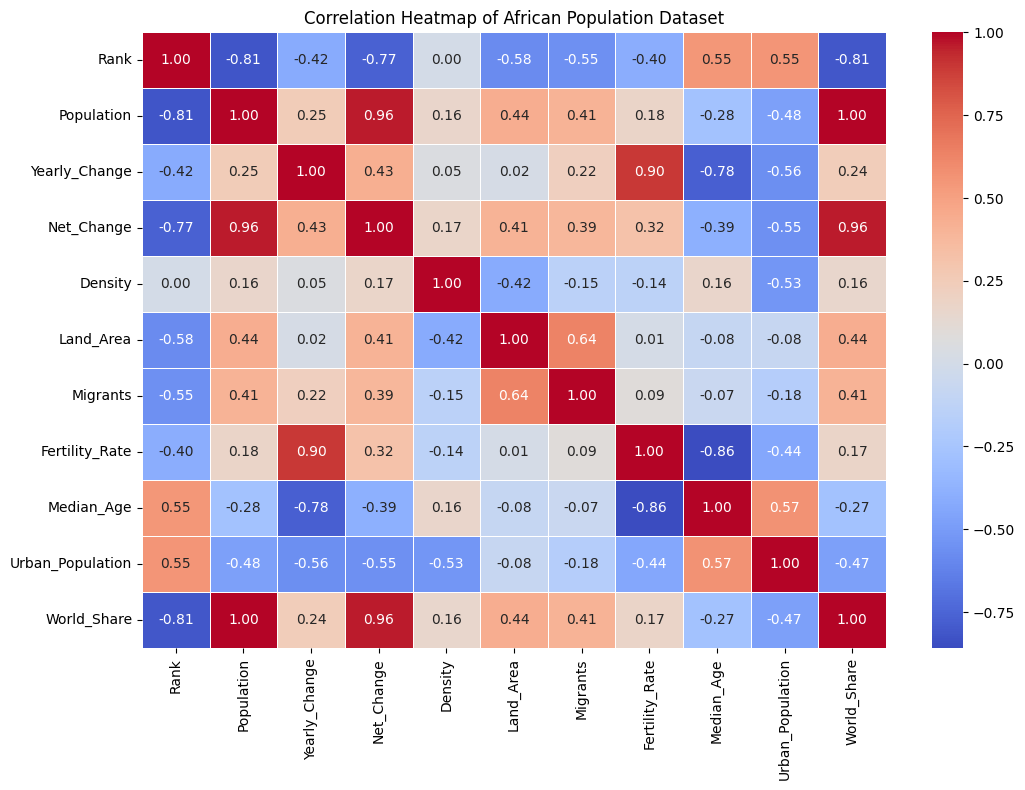

In [11]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of African Population Dataset")
plt.show()

In [12]:
data.to_csv("clean_africa_population.csv", index=False)

In [14]:
File → Download → Download .ipynb

SyntaxError: invalid character '→' (U+2192) (3694859245.py, line 1)